# Train IM1 autoencoders

In this notebook, we train 10 autoencoders, one for each digit in the MNIST dataset. 

## Setup


In [2]:
inDrive = False

In [3]:
import sys
import os

if inDrive:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir('/content/drive/My Drive/Hybrid-CLUE/MyImplementation/testing_notebooks')

# Get current directory and parent directory
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)

# Add parent directory to path if not already there
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

Import libraries

In [4]:
import importlib
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

import models.BLL
import models.mnist_classifier_BLL
import train
import sampler
import models.regene_models


Set the configuration

In [5]:
# 1. Configuration
class Config:
    # Data
    batch_size = 512
    latent_dim = 256

    # Hardware
    device = 'cuda' if torch.cuda.is_available() \
    else 'mps' if torch.backends.mps.is_available() \
    else 'cpu'

    train=False

cfg = Config()

In [6]:
models_dir = '../model_saves/im1_autoencoders'
results_dir = '../results/im1_autoencoders'
os.makedirs(models_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

In [7]:
# Load the MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor()
    ])
trainset = torchvision.datasets.MNIST(root='../data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='../data', train=False, download=True, transform=transform)

# Split training set into train and validation
train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
trainset, valset = torch.utils.data.random_split(trainset, [train_size, val_size])

trainloader = torch.utils.data.DataLoader(trainset, batch_size=cfg.batch_size, shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(valset, batch_size=cfg.batch_size, shuffle=False, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=cfg.batch_size, shuffle=False, num_workers=2)

## Training

In [13]:
from models.counterfactual_scorer import MNISTClassAutoencoders
from models.mnist_im1_autoencoder import MNISTIM1Autoencoder

importlib.reload(models.counterfactual_scorer)
importlib.reload(models.mnist_im1_autoencoder)

mnist_autoencoders = MNISTClassAutoencoders(models_dir=models_dir, device=cfg.device)
mnist_autoencoders.train_all(trainset, val_split=0.1, batch_size=64, num_epochs=100, lr=0.001, patience=20, loss_type='bce')



===== Training autoencoder for digit 0 =====
Training set size: 4311, Validation set size: 479
Epoch 1/100, Train Loss: 0.321445, Val Loss: 0.253201, LR: 0.001000
Model saved to ../model_saves/im1_autoencoders/mnist_autoencoder_class_0.pth
Epoch 2/100, Train Loss: 0.187579, Val Loss: 0.138675, LR: 0.001000
Model saved to ../model_saves/im1_autoencoders/mnist_autoencoder_class_0.pth
Epoch 3/100, Train Loss: 0.123227, Val Loss: 0.114171, LR: 0.001000
Model saved to ../model_saves/im1_autoencoders/mnist_autoencoder_class_0.pth
Epoch 4/100, Train Loss: 0.109591, Val Loss: 0.107813, LR: 0.001000
Model saved to ../model_saves/im1_autoencoders/mnist_autoencoder_class_0.pth
Epoch 5/100, Train Loss: 0.103821, Val Loss: 0.102320, LR: 0.001000
Model saved to ../model_saves/im1_autoencoders/mnist_autoencoder_class_0.pth
Epoch 6/100, Train Loss: 0.099777, Val Loss: 0.099372, LR: 0.001000
Model saved to ../model_saves/im1_autoencoders/mnist_autoencoder_class_0.pth
Epoch 7/100, Train Loss: 0.097008,


===== Training autoencoder for digit 7 =====
Training set size: 4574, Validation set size: 508
Epoch 1/100, Train Loss: 0.146947, Val Loss: 0.089295, LR: 0.001000
Model saved to ../model_saves/im1_autoencoders/mnist_autoencoder_class_7.pth
Epoch 2/100, Train Loss: 0.080214, Val Loss: 0.077354, LR: 0.001000
Model saved to ../model_saves/im1_autoencoders/mnist_autoencoder_class_7.pth
Epoch 3/100, Train Loss: 0.072766, Val Loss: 0.073835, LR: 0.001000
Model saved to ../model_saves/im1_autoencoders/mnist_autoencoder_class_7.pth
Epoch 4/100, Train Loss: 0.069183, Val Loss: 0.069792, LR: 0.001000
Model saved to ../model_saves/im1_autoencoders/mnist_autoencoder_class_7.pth
Epoch 5/100, Train Loss: 0.067043, Val Loss: 0.068309, LR: 0.001000
Model saved to ../model_saves/im1_autoencoders/mnist_autoencoder_class_7.pth
Epoch 6/100, Train Loss: 0.065426, Val Loss: 0.068568, LR: 0.001000
Epoch 7/100, Train Loss: 0.064177, Val Loss: 0.065851, LR: 0.001000
Model saved to ../model_saves/im1_autoencod

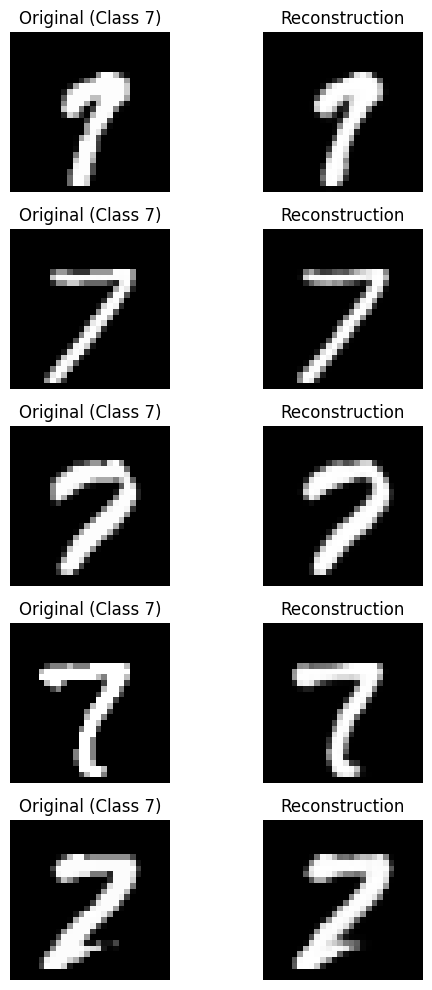

MNISTConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=6272, out_features=32, bias=True)
    (8): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (decoder_dense): Sequential(
    (0): Linear(in_features=32, out_features=6272, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3

In [10]:
from models.counterfactual_scorer import MNISTClassAutoencoders
from models.mnist_im1_autoencoder import MNISTIM1Autoencoder

importlib.reload(models.counterfactual_scorer)
importlib.reload(models.mnist_im1_autoencoder)

mnist_autoencoders = MNISTClassAutoencoders(models_dir=models_dir, device=cfg.device)
mnist_autoencoders.train_single_class(
    trainset, 
    digit_class=7, 
    val_split=0.1, 
    batch_size=16, 
    num_epochs=100, 
    lr=0.001, 
    patience=40,
    loss_type='bce'
)


Loading autoencoder for digit 0...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_0.pth
Loading autoencoder for digit 1...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_1.pth
Loading autoencoder for digit 2...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_2.pth
Loading autoencoder for digit 3...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_3.pth
Loading autoencoder for digit 4...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_4.pth
Loading autoencoder for digit 5...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_5.pth
Loading autoencoder for digit 6...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_6.pth
Loading autoencoder for digit 7...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_7.pth
Loading autoencoder for digit 8...
Model loaded from ../model_saves/im1_autoenco

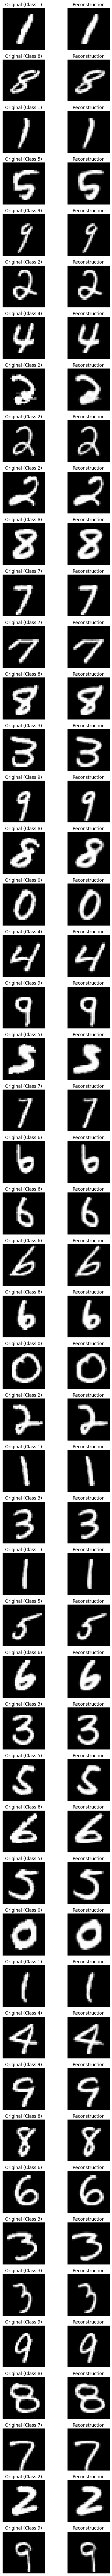

In [8]:
from models.counterfactual_scorer import MNISTClassAutoencoders
from models.mnist_conv_autoencoder import MNISTConvAutoencoder

importlib.reload(models.counterfactual_scorer)
importlib.reload(models.mnist_conv_autoencoder)

mnist_autoencoders = MNISTClassAutoencoders(models_dir=models_dir, device=cfg.device)
mnist_autoencoders.load_models()


# Get a small batch of data from the trainloader
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Take the first few samples for visualization
num_samples = 50
sample_images = images[:num_samples]
sample_labels = labels[:num_samples]

# Visualize the reconstructions
mnist_autoencoders.visualize_reconstructions(sample_images, sample_labels, num_samples=50)

Loading autoencoder for digit 0...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_0.pth
Loading autoencoder for digit 1...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_1.pth
Loading autoencoder for digit 2...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_2.pth
Loading autoencoder for digit 3...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_3.pth
Loading autoencoder for digit 4...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_4.pth
Loading autoencoder for digit 5...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_5.pth
Loading autoencoder for digit 6...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_6.pth
Loading autoencoder for digit 7...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_7.pth
Loading autoencoder for digit 8...
Model loaded from ../model_saves/im1_autoenco

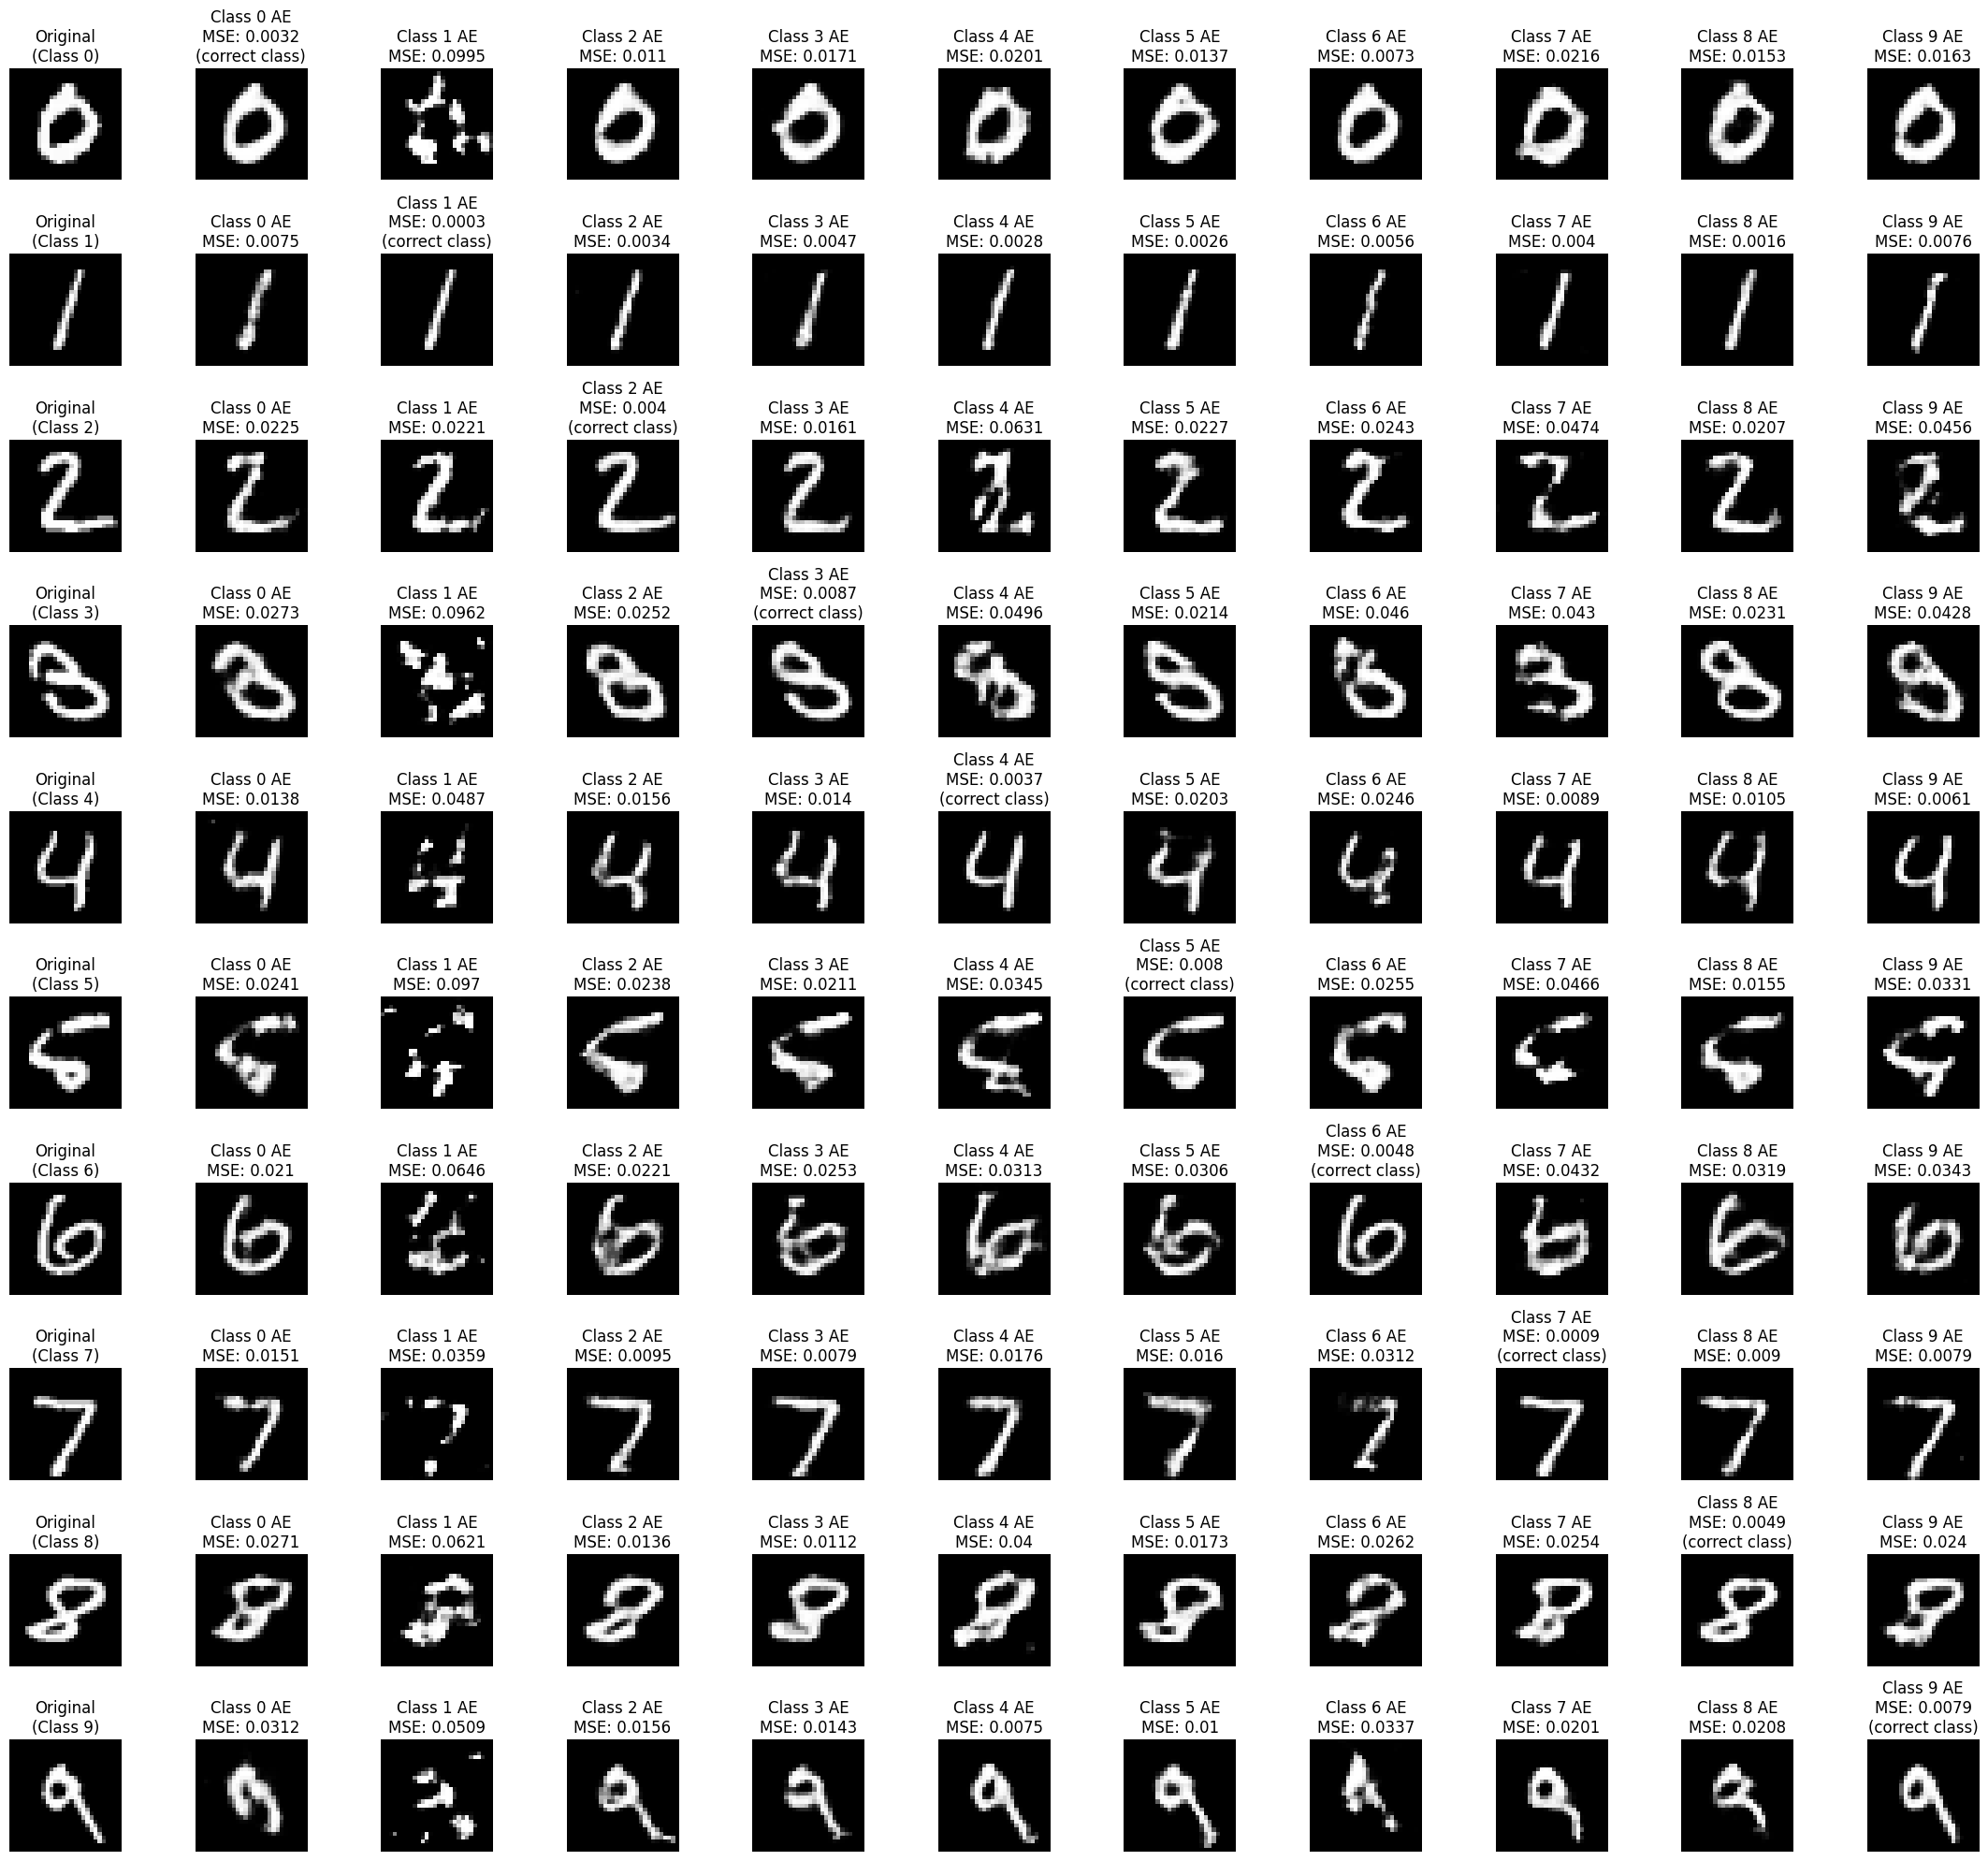

In [10]:
from models.counterfactual_scorer import MNISTClassAutoencoders
from models.mnist_conv_autoencoder import MNISTConvAutoencoder

importlib.reload(models.counterfactual_scorer)
importlib.reload(models.mnist_conv_autoencoder)

mnist_autoencoders = MNISTClassAutoencoders(models_dir=models_dir, device=cfg.device)
mnist_autoencoders.load_models()


# Get a small batch of data from the trainloader
dataiter = iter(testloader)
images, labels = next(dataiter)

# Visualize the reconstructions
mnist_autoencoders.visualize_cross_reconstructions(images, labels)